In [1]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# --- STEP 1: Load Base Models ---
# DenseNet121 Model
densenet_model_path = "C:\\Users\\ezeki\\OneDrive\\Desktop\\MTechProject\\Models\\best_densenet121_model.pth"
densenet_model = torch.hub.load('pytorch/vision:v0.10.0', 'densenet121', pretrained=False)
densenet_model.classifier = torch.nn.Linear(densenet_model.classifier.in_features, 2)
densenet_model.load_state_dict(torch.load(densenet_model_path, map_location=device))
densenet_model.to(device).eval()

Downloading: "https://github.com/pytorch/vision/zipball/v0.10.0" to C:\Users\ezeki/.cache\torch\hub\v0.10.0.zip
C:\Users\ezeki\OneDrive\Desktop\MTechProject\myenv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\ezeki\OneDrive\Desktop\MTechProject\myenv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [4]:
# ResNet50 with Dropout Model
resnet50_model_path = "C:\\Users\\ezeki\\OneDrive\\Desktop\\MTechProject\\Models\\best_resnet50_model.pth"
class ResNet50WithDropout(torch.nn.Module):
    def __init__(self, pretrained=True, num_classes=2, dropout_rate=0.5):
        super(ResNet50WithDropout, self).__init__()
        self.model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet50', pretrained=pretrained)
        num_features = self.model.fc.in_features
        self.model.fc = torch.nn.Sequential(
            torch.nn.Dropout(dropout_rate),
            torch.nn.Linear(num_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)

resnet_model = torch.load(resnet50_model_path, map_location=device, weights_only=False)
resnet_model.to(device).eval()

ResNet50WithDropout(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(


In [5]:
# Vision Transformer with Dropout Model
vit_model_path = "C:\\Users\\ezeki\\OneDrive\\Desktop\\MTechProject\\Models\\best_vit_model.pth"
class ViTWithDropout(torch.nn.Module):
    def __init__(self, base_model, dropout_rate=0.5):
        super(ViTWithDropout, self).__init__()
        self.base_model = base_model
        self.dropout = torch.nn.Dropout(p=dropout_rate)
        self.classifier = torch.nn.Linear(base_model.embed_dim, 2)

    def forward(self, x):
        x = self.base_model.forward_features(x)
        cls_token = x[:, 0, :]
        cls_token = self.dropout(cls_token)
        x = self.classifier(cls_token)
        return x

vit_model = torch.load(vit_model_path, map_location=device, weights_only=False)
vit_model.to(device).eval()

ViTWithDropout(
  (base_model): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate=

In [6]:
# --- STEP 2: Prepare DataLoader ---
# Transform for Validation and Test Dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [7]:
# Load validation dataset
val_dataset = datasets.ImageFolder("C:\\Users\\ezeki\\OneDrive\\Desktop\\MTechProject\\eyepac-light-v2-512-jpg\\validation", transform=transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Load test dataset
test_dataset = datasets.ImageFolder("C:\\Users\\ezeki\\OneDrive\\Desktop\\MTechProject\\eyepac-light-v2-512-jpg\\test", transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [8]:
# --- STEP 3: Extract Features for Meta-Model ---

def extract_features(models, loader):
    """Extract predictions from base models."""
    model1, model2, model3 = models
    features = []
    labels = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            labels.extend(targets.numpy())

            # Get predictions from each model
            preds1 = F.softmax(model1(images), dim=1).cpu().numpy()
            preds2 = F.softmax(model2(images), dim=1).cpu().numpy()
            preds3 = F.softmax(model3(images), dim=1).cpu().numpy()

            # Concatenate predictions
            combined_preds = np.hstack((preds1, preds2, preds3))
            features.append(combined_preds)

    features = np.vstack(features)
    labels = np.array(labels)
    return features, labels

# Extract features from validation data
val_features, val_labels = extract_features(models=(densenet_model, resnet_model, vit_model), loader=val_loader)


In [10]:
# Print the total number of features extracted
print(f"Total number of features extracted: {val_features.shape[1]} per sample")
print(f"Total number of samples: {val_features.shape[0]}")

Total number of features extracted: 6 per sample
Total number of samples: 770


In [11]:
# --- STEP 4: Train Meta-Model ---
meta_model = LogisticRegression()
meta_model.fit(val_features, val_labels)

LogisticRegression()

In [24]:
from sklearn.metrics import accuracy_score

# Use the meta-model to make predictions on validation data
val_preds = meta_model.predict(val_features)

# Calculate validation accuracy
val_accuracy = accuracy_score(val_labels, val_preds)
print(f"Stacked Ensemble Validation Accuracy: {val_accuracy * 100:.2f}%")

Stacked Ensemble Validation Accuracy: 95.19%


In [26]:
print("Classification Report:")
print(classification_report(val_labels, val_preds))

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       385
           1       0.95      0.96      0.95       385

    accuracy                           0.95       770
   macro avg       0.95      0.95      0.95       770
weighted avg       0.95      0.95      0.95       770



In [12]:
# --- STEP 5: Evaluate on Test Dataset ---
test_features, test_labels = extract_features(models=(densenet_model, resnet_model, vit_model), loader=test_loader)

In [13]:
# Make predictions using the meta-model
test_preds = meta_model.predict(test_features)

In [14]:
# Calculate accuracy
test_accuracy = accuracy_score(test_labels, test_preds)
print(f"Stacked Ensemble Test Accuracy: {test_accuracy * 100:.2f}%")

Stacked Ensemble Test Accuracy: 92.47%


In [19]:
# --- STEP 6: Evaluate Performance Metrics ---
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

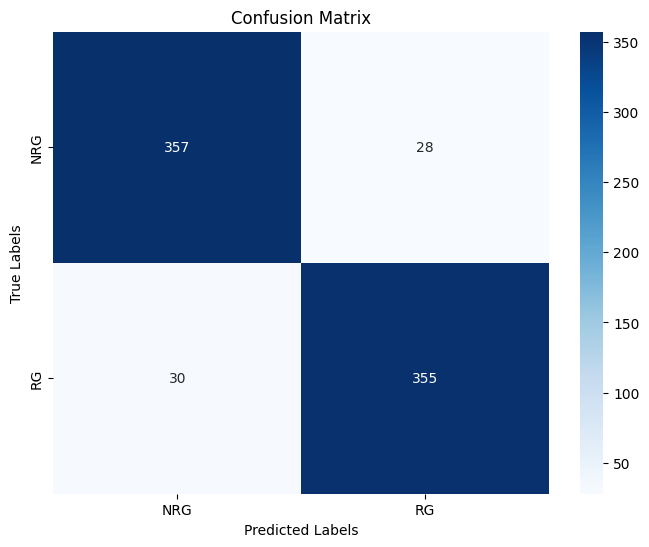

In [22]:
# Generate the confusion matrix
conf_matrix = confusion_matrix(test_labels, test_preds)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=val_dataset.classes, yticklabels=val_dataset.classes)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

In [23]:
# Generate and print the classification report
class_report = classification_report(test_labels, test_preds, target_names=val_dataset.classes)
print("Classification Report:\n", class_report)

Classification Report:
               precision    recall  f1-score   support

         NRG       0.92      0.93      0.92       385
          RG       0.93      0.92      0.92       385

    accuracy                           0.92       770
   macro avg       0.92      0.92      0.92       770
weighted avg       0.92      0.92      0.92       770



In [27]:
# --- STEP 7: Save the Meta-Model ---
meta_model_path = "C:\\Users\\ezeki\\OneDrive\\Desktop\\MTechProject\\Models\\meta_model.pkl"
joblib.dump(meta_model, meta_model_path)
print(f"Meta-model saved successfully at: {meta_model_path}")

Meta-model saved successfully at: C:\Users\ezeki\OneDrive\Desktop\MTechProject\Models\meta_model.pkl


In [28]:
from PIL import Image
import numpy as np

# Function to preprocess the image
def preprocess_image(image_path):
    """Preprocess a single image for model prediction."""
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image = Image.open(image_path).convert("RGB")
    return transform(image).unsqueeze(0)  # Add batch dimension

# Path to the image
image_path = "C:\\Users\\ezeki\\OneDrive\\Desktop\\MTechProject\\eyepac-light-v2-512-jpg\\test\\RG\\EyePACS-TRAIN-RG-2899.jpg"

# Preprocess the image
image_tensor = preprocess_image(image_path).to(device)

# Get predictions from each base model
with torch.no_grad():
    densenet_preds = F.softmax(densenet_model(image_tensor), dim=1).cpu().numpy()
    resnet_preds = F.softmax(resnet_model(image_tensor), dim=1).cpu().numpy()
    vit_preds = F.softmax(vit_model(image_tensor), dim=1).cpu().numpy()

# Combine predictions from base models
combined_preds = np.hstack((densenet_preds, resnet_preds, vit_preds))

# Predict using the meta-model
final_prediction = meta_model.predict(combined_preds)

# Map the prediction to class names
class_names = val_dataset.classes  # Assumes the dataset has a `classes` attribute
predicted_class = class_names[final_prediction[0]]

print(f"Predicted Class: {predicted_class}")


Predicted Class: RG
